In [ ]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from google.colab import drive

drive.mount('/content/gdrive')

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# read in the merged station datasets
dfs = {}
for index in range(0, 6) :
  df = pd.read_csv('/content/gdrive/MyDrive/Colab Notebooks/merged_' + str(index + 1) + '.dat', sep=",", parse_dates=["Date"], index_col="Date")
  dfs['Station' + str(index + 1)] = df
print(len(dfs))
dfs['Station1'].head()

6


,Ppt_x,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag,Ppt_y,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,3,0.0,-1.090,81.5,1.052,52.27,0.63
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,3,0.0,-1.038,81.7,0.959,46.71,0.62
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,3,0.0,-0.981,82.0,1.062,52.04,0.60
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,3,0.0,-0.814,81.9,0.887,58.91,0.64
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,3,0.0,-0.805,90.0,0.828,16.55,0.20


In [ ]:
# statistics of the station 1 dataset for example
dfs['Station1'].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Ppt_x,57859.0,0.068852,0.857941,0.000,0.000,0.000,0.000,42.160
SWC_5,57795.0,0.142987,0.052115,0.043,0.098,0.137,0.186,0.309
SWC_10,57846.0,0.156679,0.040268,0.084,0.123,0.155,0.190,0.298
SWC_20,57649.0,0.138416,0.033171,0.086,0.106,0.139,0.166,0.235
SWC_50,57834.0,0.138174,0.035402,0.087,0.104,0.130,0.170,0.249
T_5,57859.0,22.927269,9.519754,0.760,15.500,22.940,30.050,49.960
T_10,57859.0,22.934645,8.910221,1.780,15.740,23.090,30.150,44.440
T_20,57859.0,22.868688,8.425604,2.760,15.880,23.040,30.010,41.200
T_50,57859.0,22.693762,7.055595,5.960,16.380,22.540,29.210,35.400
Flag,58441.0,185.475967,1434.941793,0.000,0.000,0.000,0.000,13107.000


In [ ]:
# Check if dfs contains NaN values
for station, df in dfs.items() :
  print(station)
  print(df.isnull().sum())
  print()

Station1
Ppt_x            582
SWC_5            646
SWC_10           595
SWC_20           792
SWC_50           607
T_5              582
T_10             582
T_20             582
T_50             582
Flag               0
Ppt_y            583
Tair             588
RH               583
Windspeed        583
Winddirection    583
Srad             583
dtype: int64

Station2
Ppt_x            0
SWC_5            2
SWC_10           1
SWC_20           1
SWC_50           0
T_5              0
T_10             0
T_20             0
T_50             0
Flag             0
Ppt_y            0
Tair             0
RH               0
Windspeed        0
Winddirection    0
Srad             0
dtype: int64

Station3
Ppt_x             0
SWC_5             0
SWC_10            0
SWC_20            0
SWC_50            0
T_5               0
T_10              0
T_20              0
T_50              0
Flag              0
Ppt_y             0
Tair              0
RH                0
Windspeed         0
Winddirection     0
Srad 

Station 4 has completely null columns for SWC_50 and T_50. I can't train on null values. To keep the integrity of the training, I chose not to impute those two entire columns with a constant value (which might mess up learning). I am choosing to remove Station 4 from analysis until a potential fix for this issue and to allow for optimal training.

In [ ]:
del dfs['Station4']
print(dfs.keys())

dict_keys(['Station1', 'Station2', 'Station3', 'Station5', 'Station6'])


In [ ]:
# drop NaN values to prevent issues when training (if NaN values are left in the df, loss cannot compute and training cannot occur)
for station, df in dfs.items() :
  print(station)
  df_new = df.dropna()
  print(df_new.isnull().sum())
  dfs[station] = df_new
  print()

Station1
Ppt_x            0
SWC_5            0
SWC_10           0
SWC_20           0
SWC_50           0
T_5              0
T_10             0
T_20             0
T_50             0
Flag             0
Ppt_y            0
Tair             0
RH               0
Windspeed        0
Winddirection    0
Srad             0
dtype: int64

Station2
Ppt_x            0
SWC_5            0
SWC_10           0
SWC_20           0
SWC_50           0
T_5              0
T_10             0
T_20             0
T_50             0
Flag             0
Ppt_y            0
Tair             0
RH               0
Windspeed        0
Winddirection    0
Srad             0
dtype: int64

Station3
Ppt_x            0
SWC_5            0
SWC_10           0
SWC_20           0
SWC_50           0
T_5              0
T_10             0
T_20             0
T_50             0
Flag             0
Ppt_y            0
Tair             0
RH               0
Windspeed        0
Winddirection    0
Srad             0
dtype: int64

Station5
Ppt_x     

In [ ]:
for station, df in dfs.items() :
  # drop the Flag feature (it is not relevant to our soil data and can cause our ML model to pick on unneccesary patterns)
  df = df.drop('Flag', axis = 1)
  # rename Ppt columns to identify whether the precipitation was recorded as a part of soil data or meteorological data
  df_new = df.rename(columns = {'Ppt_x' : 'Ppt_soil', 'Ppt_y': 'Ppt_met'})
  print(station)
  print(df_new.describe().transpose())
  dfs[station] = df_new
  print()

Station1
                 count        mean         std      min       25%      50%  \
Ppt_soil       57586.0    0.068296    0.851118    0.000    0.0000    0.000   
SWC_5          57586.0    0.142906    0.052128    0.043    0.0980    0.137   
SWC_10         57586.0    0.156554    0.040289    0.084    0.1220    0.155   
SWC_20         57586.0    0.138393    0.033162    0.086    0.1060    0.139   
SWC_50         57586.0    0.138267    0.035442    0.087    0.1040    0.130   
T_5            57586.0   22.889934    9.522205    0.760   15.4600   22.890   
T_10           57586.0   22.899269    8.913519    1.780   15.7025   23.020   
T_20           57586.0   22.835817    8.430082    2.760   15.8400   22.980   
T_50           57586.0   22.667777    7.061287    5.960   16.3500   22.470   
Ppt_met        57586.0    0.068336    0.851120    0.000    0.0000    0.000   
Tair           57586.0   14.858769   22.046219 -173.200   12.0200   19.480   
RH             57586.0   64.900222   28.543891  -96.300

Text(0, 0.5, 'Wind Velocity [m/s]')

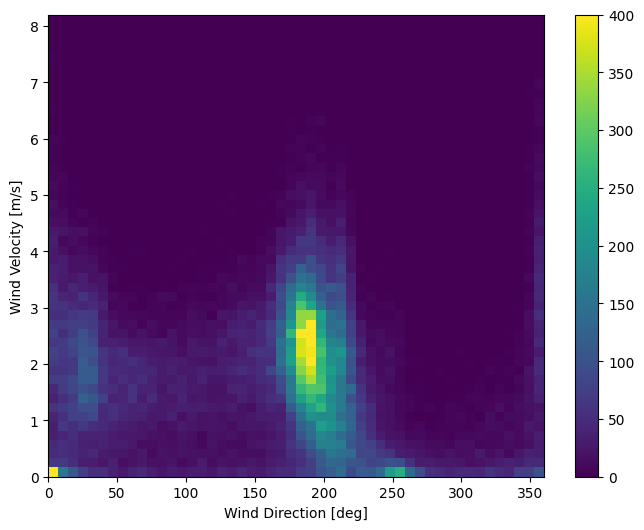

In [ ]:
# distribution of wind data (station 1 for example)
plt.hist2d(dfs['Station1']['Winddirection'], dfs['Station1']['Windspeed'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind Direction [deg]')
plt.ylabel('Wind Velocity [m/s]')

In [ ]:
for station, df in dfs.items() :
  # convert wind velocity and wind direction to a wind vector
  wv = df.pop('Windspeed')

  # Convert to radians.
  wd_rad = df.pop('Winddirection')*np.pi / 180

  # Calculate the wind x and y components.
  df['Wx'] = wv*np.cos(wd_rad)
  df['Wy'] = wv*np.sin(wd_rad)
  dfs[station] = df

(-7.808186098707588, 8.1975522162057, -4.273160359540029, 4.754479689602174)

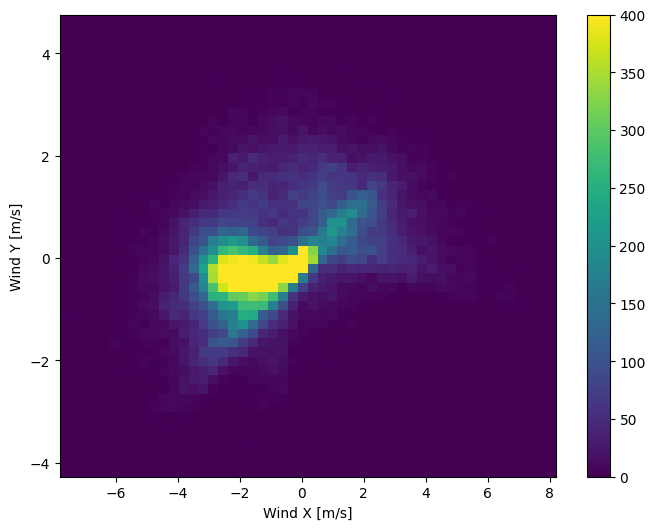

In [ ]:
# The distribution of wind vectors is much simpler for the model to correctly interpret (station 1 for example)
plt.hist2d(dfs['Station1']['Wx'], dfs['Station1']['Wy'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
ax = plt.gca()
ax.axis('tight')

In [ ]:
# Remove periodicity in time data (remove daily and yearly periodicity)
day = 24*60*60
year = (365.2425)*day

for station, df in dfs.items() :
  timestamp_s = (df.index).map(pd.Timestamp.timestamp)

  df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
  df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
  df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
  df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

  dfs[station] = df

Text(0.5, 1.0, 'Time of day signal')

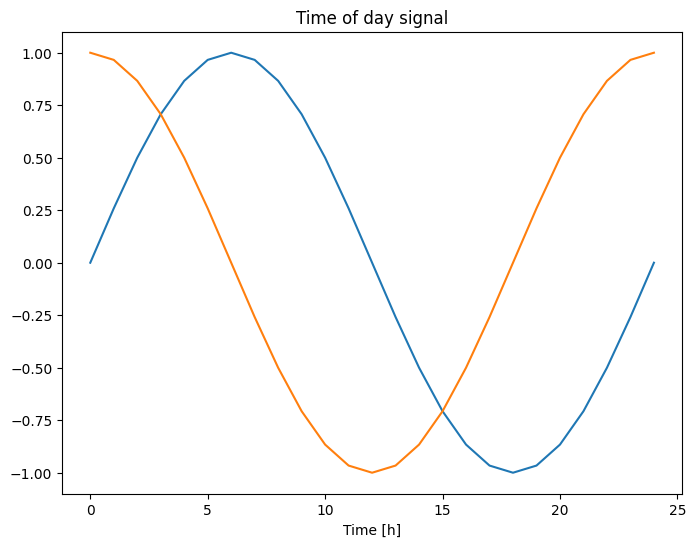

In [ ]:
# plot day sin and cos (station 1 for example)
plt.plot(np.array(dfs['Station1']['Day sin'])[:25])
plt.plot(np.array(dfs['Station1']['Day cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

In [ ]:
# Split the dataset into train, validation, and test sets
# 2015-2020 (training data), 2021 (validation data [every station except station 3]), Station 3 2021 (testing data)
column_indices = {name: i for i, name in enumerate(dfs['Station1'].columns)}

train_list = []
val_list = []

# get all training dfs from each station
for station, df in dfs.items() :
  df = df.loc['2015':'2020']
  train_list.append(df)

# get all validation dfs from each station
for station, df in dfs.items() :
  if station == 'Station3' :
    continue
  df = df.loc['2021']
  val_list.append(df)

# create a merged, singular train_df
train_df = None
not_set = True
for df in train_list :
    if not_set :
      train_df = df
      not_set = False
      continue
    train_df = train_df.append(df, ignore_index=True)

# create a merged, singular val_df
val_df = None
not_set = True
for df in val_list :
    if not_set :
      val_df = df
      not_set = False
      continue
    val_df = val_df.append(df, ignore_index=True)

# get the testing df
test_df = dfs['Station3'].loc['2021']

print('years in train df: ' + str((len(train_df) / 24 / 365)))
print('years in val df: ' + str((len(val_df) / 24 / 365)))
print('years in test df: ' + str((len(test_df) / 24 / 365)))

num_features = dfs['Station1'].shape[1]

years in train df: 28.69497716894977
years in val df: 2.426598173515982
years in test df: 0.6658675799086757


<ipython-input-88-cd67ec8c87e0>:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  train_df = train_df.append(df, ignore_index=True)
<ipython-input-88-cd67ec8c87e0>:38: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  val_df = val_df.append(df, ignore_index=True)


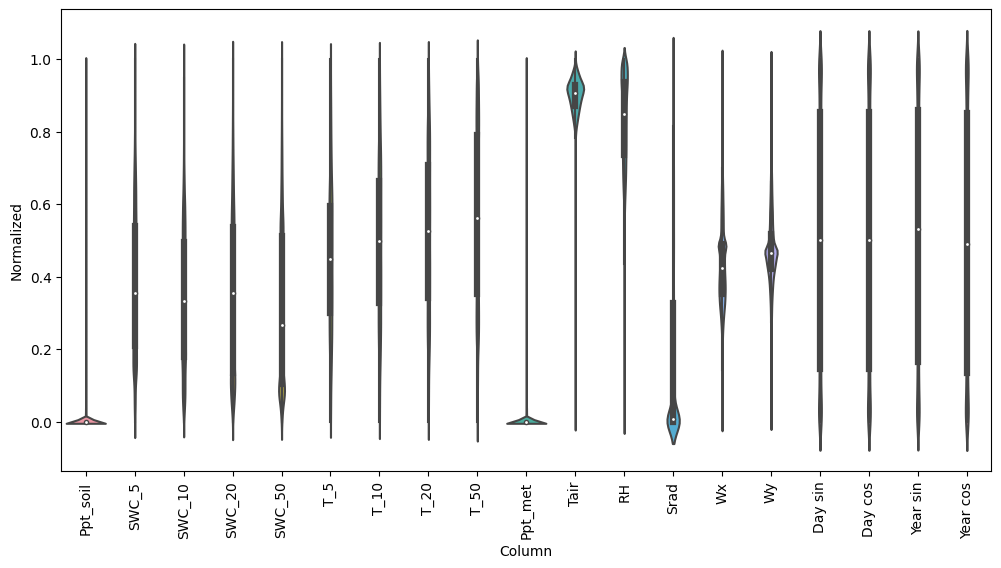

In [ ]:
# normalize the data (using min-max normalization)
train_df = (train_df - train_df.min()) / (train_df.max() - train_df.min())
val_df = (val_df - val_df.min()) / (val_df.max() - val_df.min())
test_df = (test_df - test_df.min()) / (test_df.max() - test_df.min())

# look at distribution of values (Station 1 for example)
df_std = (dfs['Station1'] - dfs['Station1'].min()) / (dfs['Station1'].max() - dfs['Station1'].min())
df_std = df_std.melt(var_name='Column', value_name='Normalized')
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
_ = ax.set_xticklabels(dfs['Station1'].keys(), rotation=90)

In [ ]:
# create window generator class
class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=train_df, val_df=val_df, test_df=test_df,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}'])

In [ ]:
# create windowing function
def split_window(self, features):
  inputs = features[:, self.input_slice, :]
  labels = features[:, self.labels_slice, :]
  if self.label_columns is not None:
    labels = tf.stack(
        [labels[:, :, self.column_indices[name]] for name in self.label_columns],
        axis=-1)

  # Slicing doesn't preserve static shape information, so set the shapes
  # manually. This way the `tf.data.Datasets` are easier to inspect.
  inputs.set_shape([None, self.input_width, None])
  labels.set_shape([None, self.label_width, None])

  return inputs, labels

WindowGenerator.split_window = split_window

In [ ]:
# simple visualization of the window
def plot(self, model=None, plot_col='SWC_5', max_subplots=3):
  inputs, labels = self.example
  plt.figure(figsize=(12, 8))
  plot_col_index = self.column_indices[plot_col]
  max_n = min(max_subplots, len(inputs))
  for n in range(max_n):
    plt.subplot(max_n, 1, n+1)
    plt.ylabel(f'{plot_col} [normed]')
    plt.plot(self.input_indices, inputs[n, :, plot_col_index],
             label='Inputs', marker='.', zorder=-10)

    if self.label_columns:
      label_col_index = self.label_columns_indices.get(plot_col, None)
    else:
      label_col_index = plot_col_index

    if label_col_index is None:
      continue

    plt.scatter(self.label_indices, labels[n, :, label_col_index],
                edgecolors='k', label='Labels', c='#2ca02c', s=64)
    if model is not None:
      predictions = model(inputs)
      plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                  marker='X', edgecolors='k', label='Predictions',
                  c='#ff7f0e', s=64)

    if n == 0:
      plt.legend()

  plt.xlabel('Time [h]')

WindowGenerator.plot = plot

In [ ]:
# make dataset from a tf.data.Dataset of (input_window, label_window) pairs 
def make_dataset(self, data):
  data = np.array(data, dtype=np.float32)
  ds = tf.keras.utils.timeseries_dataset_from_array(
      data=data,
      targets=None,
      sequence_length=self.total_window_size,
      sequence_stride=1,
      shuffle=True,
      batch_size=32,)

  ds = ds.map(self.split_window)

  return ds

WindowGenerator.make_dataset = make_dataset

In [ ]:
# Add properties for accessing train, val, and test data as tf.data.Datasets using the make_dataset method you defined earlier
# Also, add a standard example batch for easy access and plotting
@property
def train(self):
  return self.make_dataset(self.train_df)

@property
def val(self):
  return self.make_dataset(self.val_df)

@property
def test(self):
  return self.make_dataset(self.test_df)

@property
def example(self):
  """Get and cache an example batch of `inputs, labels` for plotting."""
  result = getattr(self, '_example', None)
  if result is None:
    # No example batch was found, so get one from the `.train` dataset
    result = next(iter(self.train))
    # And cache it for next time
    self._example = result
  return result

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

In [ ]:
# generate a wide window of 7 days of consecutive inputs and labels
days = 7

wide_window = WindowGenerator(
    input_width=24 * days, label_width=24 * days, shift=1,
    label_columns=['SWC_5'])

wide_window

Total window size: 169
Input indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167]
Label indices: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65 

In [ ]:
# training procedure
MAX_EPOCHS = 100

val_performance = {}
performance = {}

def compile_and_fit(model, window, patience=2):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(learning_rate = 0.001),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history

In [ ]:
# Create a RNN LSTM model where return_sequences is True (predicts an output for each input along the way)
lstm_model = tf.keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    tf.keras.layers.LSTM(32, activation='tanh', return_sequences=True),
    tf.keras.layers.LSTM(16, activation='tanh', return_sequences=True),
    # Shape => [batch, time, features]
    tf.keras.layers.Dense(units=1)
])

In [ ]:
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', lstm_model(wide_window.example[0]).shape)

Input shape: (32, 168, 19)
Output shape: (32, 168, 1)


In [ ]:
# train and evaluate the RNN LSTM model
history = compile_and_fit(lstm_model, wide_window)

#IPython.display.clear_output()
val_performance['LSTM'] = lstm_model.evaluate(wide_window.val)
performance['LSTM'] = lstm_model.evaluate(wide_window.test, verbose=0)

Epoch 1/100
7850/7850 [==============================] - 135s 17ms/step - loss: 3.4049e-04 - mean_absolute_error: 0.0054 - val_loss: 5.9698e-05 - val_mean_absolute_error: 0.0029
Epoch 2/100
7850/7850 [==============================] - 131s 17ms/step - loss: 1.6615e-05 - mean_absolute_error: 0.0021 - val_loss: 6.0673e-05 - val_mean_absolute_error: 0.0039
Epoch 3/100
7850/7850 [==============================] - 127s 16ms/step - loss: 1.3031e-05 - mean_absolute_error: 0.0016 - val_loss: 4.8144e-05 - val_mean_absolute_error: 0.0020
Epoch 4/100
7850/7850 [==============================] - 126s 16ms/step - loss: 1.1582e-05 - mean_absolute_error: 0.0015 - val_loss: 4.5783e-05 - val_mean_absolute_error: 0.0018
Epoch 5/100
7850/7850 [==============================] - 125s 16ms/step - loss: 1.0632e-05 - mean_absolute_error: 0.0013 - val_loss: 4.5903e-05 - val_mean_absolute_error: 0.0016
Epoch 6/100
660/660 [==============================] - 6s 9ms/step - loss: 4.6543e-05 - mean_absolute_error: 0

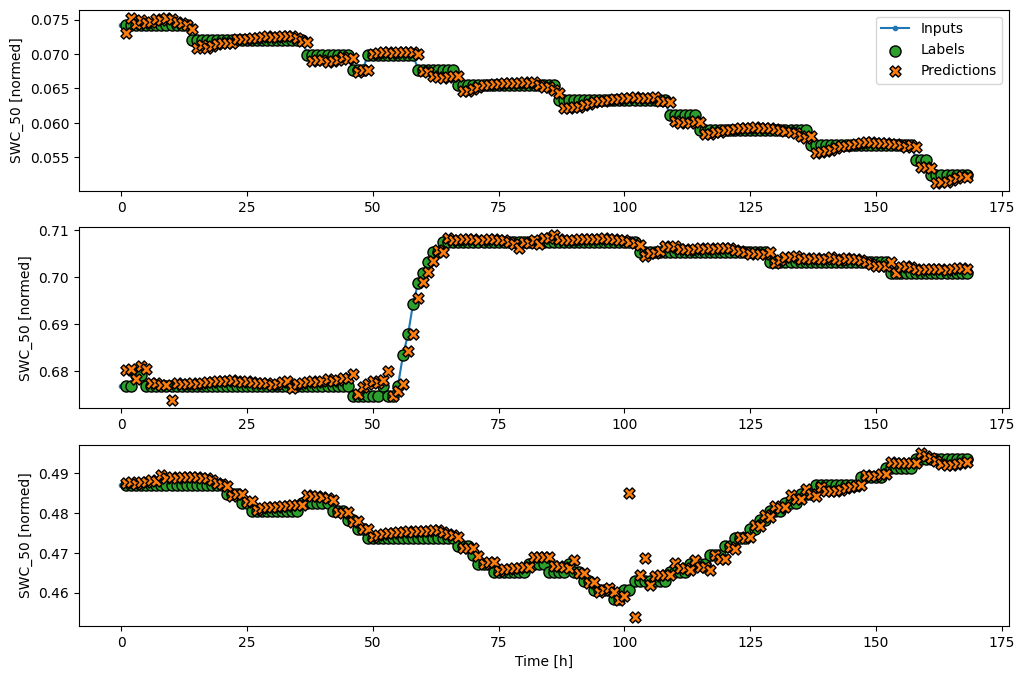

In [ ]:
'''
# plot the results of the model
wide_window.plot(lstm_model)
'''

Do a cross-validation loop to train LSTM RNN model over all the stations. The CV Loop architecture is as follows: 3 training stations, 1 validation station, and 1 testing station.
- CV Loop is 5-fold and trains the 3 training datasets against the 1 validation dataset in each iteration
- after each iteration, an accuracy and loss is obtained by testing against the testing dataset
- datasets change each iteration in a sliding window fashion (as demonstrated in the image below)
  - however, the split percentages are actually as follows: training (60%), validation (20%), testing (20%)
- as a result, we get 5 LSTM RNN models with 5 accuracies and losses -> average the losses of all 5 models


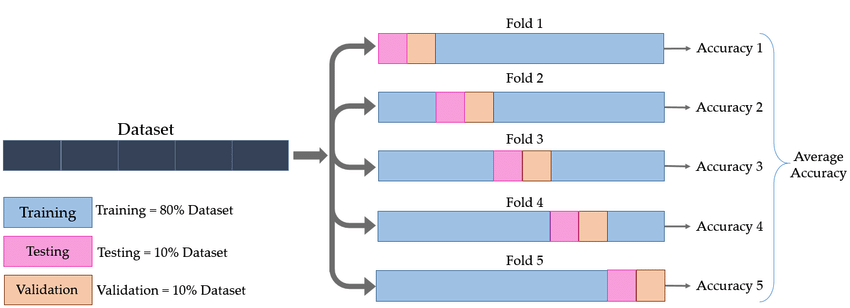

In [ ]:
# based on the fold number, obtain the correct train, val, and test datasets
def get_split(fold_idx) :

  # lists to hold all cutoffs based on fold_idx
  train_c = [('2017', '2018', '2019', '2020', '2021'), 
             ('2015', '2018', '2019', '2020', '2021'),
             ('2015', '2016', '2019', '2020', '2021'),
             ('2015', '2016', '2017', '2020', '2021'),
             ('2015', '2016', '2017', '2018', '2021'),
             ('2015', '2016', '2017', '2018', '2019'),
             ('2016', '2017', '2018', '2019', '2020')]
  val_c = ['2016', '2017', '2018', '2019', '2020', '2021', '2015']
  test_c = ['2015', '2016', '2017', '2018', '2019', '2020', '2021']
                                                    
  # Split the dataset into train, validation, and test sets
  column_indices = {name: i for i, name in enumerate(dfs['Station1'].columns)}

  train_list = []
  val_list = []
  test_list = []

  # get all training dfs from each station
  for station, df in dfs.items() :
    train_yrs = train_c[fold_idx]
    # get the appropriate training years from each station
    for year in train_yrs :
      train_list.append(df.loc[year])

  # get all validation dfs from each station
  for station, df in dfs.items() :
    val_list.append(df.loc[val_c[fold_idx]])
  
  # get the testing df
  for station, df in dfs.items() :
    test_list.append(df.loc[test_c[fold_idx]])

  # create a merged, singular train_df
  train_df = None
  not_set = True
  for df in train_list :
      if not_set :
        train_df = df
        not_set = False
        continue
      train_df = train_df.append(df, ignore_index=True)

  # create a merged, singular val_df
  val_df = None
  not_set = True
  for df in val_list :
      if not_set :
        val_df = df
        not_set = False
        continue
      val_df = val_df.append(df, ignore_index=True)

  # create a merged, singular test_df
  test_df = None
  not_set = True
  for df in test_list :
      if not_set :
        test_df = df
        not_set = False
        continue
      test_df = test_df.append(df, ignore_index=True)

  print('years in train df: ' + str((len(train_df) / 24 / 365)))
  print('years in val df: ' + str((len(val_df) / 24 / 365)))
  print('years in test df: ' + str((len(test_df) / 24 / 365)))

  return train_df, val_df, test_df

In [ ]:
# normalize the train_df, val_df, and test_df
def normalize(train_df, val_df, test_df) :
  # normalize the data (using min-max normalization)
  train_df = (train_df - train_df.min()) / (train_df.max() - train_df.min())
  val_df = (val_df - val_df.min()) / (val_df.max() - val_df.min())
  test_df = (test_df - test_df.min()) / (test_df.max() - test_df.min())

  # look at distribution of values (Station 1 for example)
  df_std = (dfs['Station1'] - dfs['Station1'].min()) / (dfs['Station1'].max() - dfs['Station1'].min())
  df_std = df_std.melt(var_name='Column', value_name='Normalized')
  plt.figure(figsize=(12, 6))
  ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
  _ = ax.set_xticklabels(dfs['Station1'].keys(), rotation=90)

  return train_df, val_df, test_df

In [ ]:
def generate_lstm() : 
  # Create a RNN LSTM model where return_sequences is True (predicts an output for each input along the way)
  lstm_model = tf.keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    tf.keras.layers.LSTM(32, activation='tanh', return_sequences=True),
    tf.keras.layers.LSTM(16, activation='tanh', return_sequences=True),
    # Shape => [batch, time, features]
    tf.keras.layers.Dense(units=1)
  ])

  return lstm_model

In [1]:
# Define the number of folds
n_folds = 7
days = 7

# Loop over the folds
for fold_idx in range(n_folds) :
    print(f'Fold {fold_idx + 1}')

    # modify the train, val, and test sets
    train_df, val_df, test_df = get_split(fold_idx)

    # normalize the datasets
    train_df, val_df, test_df = normalize(train_df, val_df, test_df)

    # generate the wide window to train on in this fold
    wide_window = WindowGenerator(
      input_width=24 * days, label_width=24 * days, shift=1,
      train_df=train_df, val_df=val_df, test_df=test_df,
      label_columns=['SWC_50'])
    
    # get the RNN LSTM model
    lstm_model = generate_lstm()
    
    # train and evaluate the RNN LSTM model
    history = compile_and_fit(lstm_model, wide_window)
    
    # Evaluate the model on the validation and test sets
    val_performance['LSTM_fold-' + str(fold_idx + 1)] = lstm_model.evaluate(wide_window.val)
    performance['LSTM_fold-' + str(fold_idx + 1)] = lstm_model.evaluate(wide_window.test, verbose=0)

    # plot the results of the model
    wide_window.plot(lstm_model)
    print()

SyntaxError: ignored